# Visual Exploration: Readers group

1. Overall response distribution

2. Counts and proportions by condition
    - Goal Type
    - Agency
    - Goal Type x Agency

Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

Load data

In [2]:
responses = pd.read_csv("../../data/raw/counterfactual_responses_raw.csv")
metadata = pd.read_csv("../../data/raw/metadata_raw.csv")

Clean data

In [3]:
responses["Response"] = responses["Response"].str.strip()

responses = responses.rename(columns= {"Partcipant_ID": "Participant_ID"})

Slice by focus: "readers" or "other-focus"

In [4]:
responses_focus = responses[responses["Focus"] == "They"].copy()

## 1. Overall response distribution

**Overall response distribution plot for Readers**

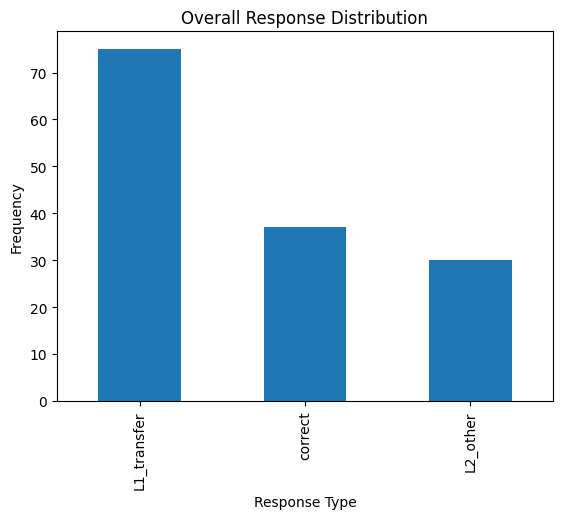

In [5]:
responses_focus["Response"].value_counts().plot(kind ="bar")

plt.title("Overall Response Distribution")
plt.xlabel("Response Type")
plt.ylabel("Frequency")
plt.show()

Clearly, transfer goes back to dominating the response landscape for readers the way it did before splitting the data into actors vs. readers. In fact, there seem to be way fewer correct responses. 

**Overall response counts and proportions for Readers**

In [6]:
pd.crosstab(
    responses_focus["Goal_Type"],
    responses_focus["Response"]
)

Response,L1_transfer,L2_other,correct
Goal_Type,,,
goal_frequent,22,10,16
goal_non_frequent,30,6,11
no_goal,23,14,10


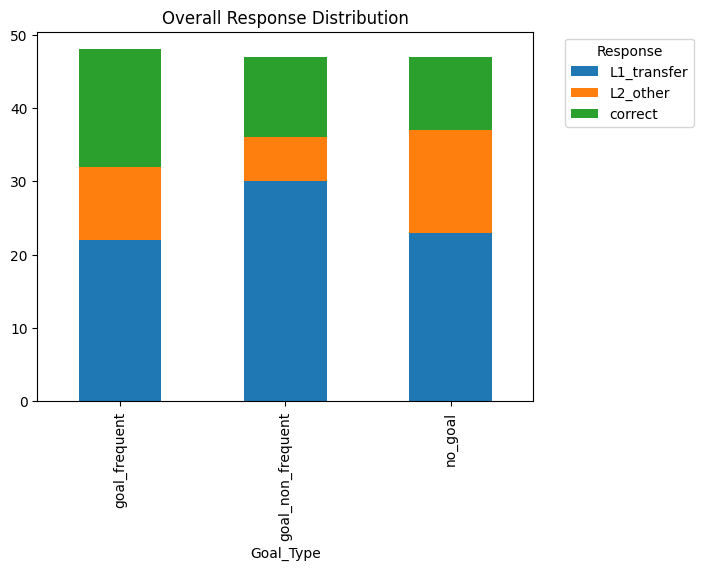

In [15]:
pd.crosstab(
    responses_focus["Goal_Type"],
    responses_focus["Response"]
).plot(kind="bar", stacked= True)

plt.title("Overall Response Distribution")
plt.legend(title="Response", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

## 2. Counts and proportions by condition

**Responses by Goal Type:**

- Counts
- Proportions 
- Proportions plot

In [16]:
goal_reponse_counts = pd.crosstab(
    responses_focus["Goal_Type"],
    responses_focus["Response"],
    dropna= False,
    margins= True
)

goal_reponse_counts

Response,L1_transfer,L2_other,correct,NaN,All
Goal_Type,,,,,
goal_frequent,22,10,16,0,48
goal_non_frequent,30,6,11,1,48
no_goal,23,14,10,1,48
All,75,30,37,2,144


In [9]:
goal_reponse_props = pd.crosstab(
    responses_focus["Goal_Type"],
    responses_focus["Response"],
    normalize= "index",
    dropna= False
)

goal_reponse_props

Response,L1_transfer,L2_other,correct,NaN
Goal_Type,,,,
goal_frequent,0.458333,0.208333,0.333333,0.000000
goal_non_frequent,0.625000,0.125000,0.229167,0.020833
no_goal,0.479167,0.291667,0.208333,0.020833


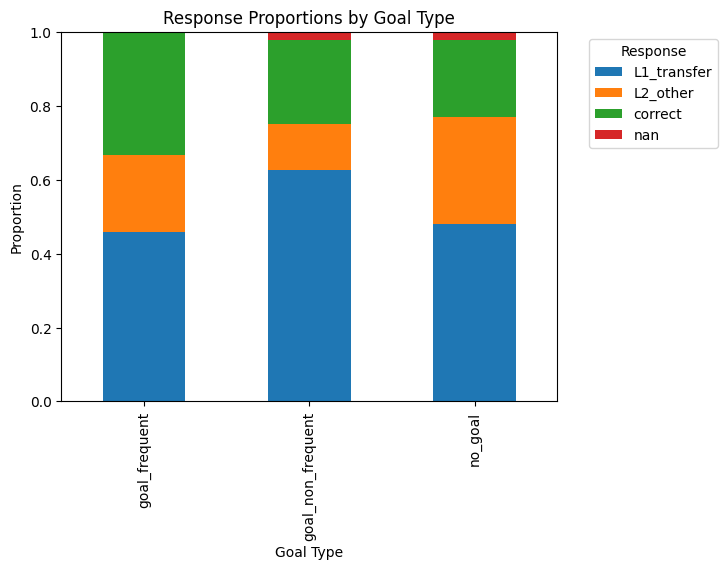

In [10]:
goal_reponse_props.plot(kind= "bar", stacked= True)

plt.title("Response Proportions by Goal Type")
plt.xlabel("Goal Type")
plt.ylabel("Proportion")
plt.legend(title= "Response", bbox_to_anchor= (1.05,1), loc = "upper left")
plt.show()

The readers data split by goal type shows that:

- goal_frequent keeps showing to be the most supportive condition for succesful, or grammatically correct, resolution. 
- no_goal produce fewer correct responses, higher alternative L2 approximations and a very similar proportion of transfer responses. 
- goal_non_frequent shows the highest proportion of L1 transfer responses (0.62), higher than in the actors data (0.39).

**Responses by Agent:**

- Counts
- Proportions 
- Proportions plot

In [17]:
agent_response_counts = pd.crosstab(
    responses_focus["Agent"],
    responses_focus["Response"],
    dropna= False,
    margins= True
)

agent_response_counts

Response,L1_transfer,L2_other,correct,NaN,All
Agent,,,,,
0,40,22,20,2,84
1,35,8,17,0,60
All,75,30,37,2,144


In [11]:
agent_response_props = pd.crosstab(
    responses_focus["Agent"],
    responses_focus["Response"],
    normalize= "index",
    dropna= False
)

agent_response_props

Response,L1_transfer,L2_other,correct,NaN
Agent,,,,
0,0.476190,0.261905,0.238095,0.02381
1,0.583333,0.133333,0.283333,0.00000


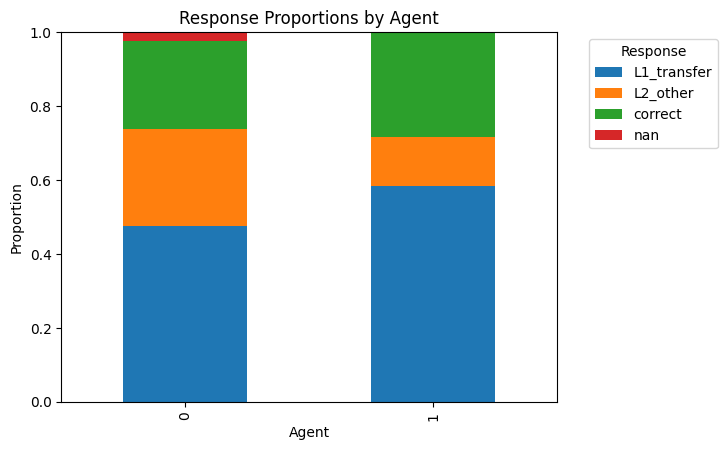

In [12]:
agent_response_props.plot(kind= "bar", stacked= True)

plt.title("Response Proportions by Agent")
plt.xlabel("Agent")
plt.ylabel("Proportion")
plt.legend(title = "Response", bbox_to_anchor =(1.05, 1), loc = "upper left")
plt.show()

Now, it looks like agency does not seem to assist in how learners solve the problem the same way for readers:

- When there is an explicit Agent (Agent = 1) in the antecedent: 

    - learners keep commiting more strongly to a representation, either by means of a correct or a transfer response; yet, compared to the actors data data, resolution by transfer is higher (0.43 vs 0.58) and correct resolution lower (0.38 vs. 0.28).
    - there aren't any null responses

- When there isn't an explicit Agent (Agent = 0) in the antecedent: 

    - proportion for more L2 interpretations keeps being higher than its counterpart but no different from the actors data. However, compared to the actors data, the proportion of correct responses is lower (0.23 vs. 0.32) and higher of transfer responses (0.47 vs. 0.35).
    - As expected by now, the only 2 null values in the readers data, again, are here. 

**Responses by Goal Type and Agent:**

- Counts
- Proportions 
- Proportions plot

In [13]:
goal_agent_response_props = pd.crosstab(
    [responses_focus["Goal_Type"], responses_focus["Agent"]],
    responses_focus["Response"],
    normalize= "index",
    dropna= False
)

goal_agent_response_props

Response                 L1_transfer  L2_other   correct       NaN
Goal_Type         Agent                                           
goal_frequent     0         0.357143  0.321429  0.321429  0.000000
                  1         0.600000  0.050000  0.350000  0.000000
goal_non_frequent 0         0.642857  0.107143  0.214286  0.035714
                  1         0.600000  0.150000  0.250000  0.000000
no_goal           0         0.428571  0.357143  0.178571  0.035714
                  1         0.550000  0.200000  0.250000  0.000000

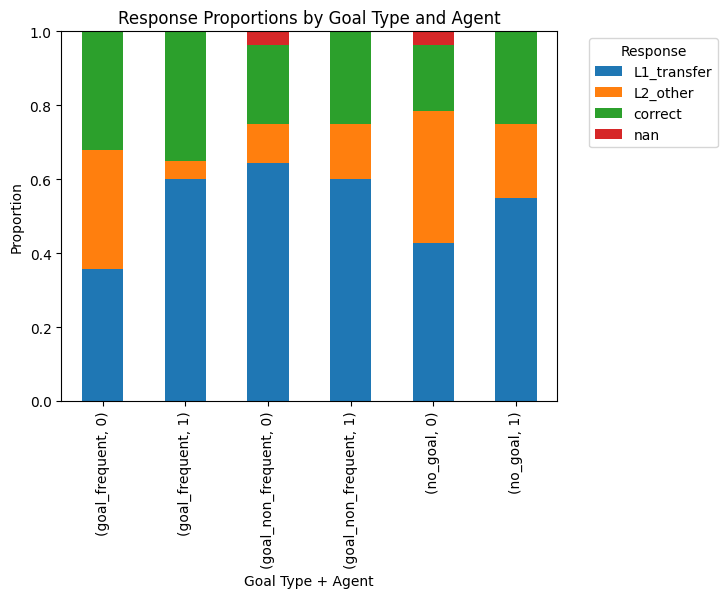

In [14]:
goal_agent_response_props.plot(kind= "bar", stacked= True)

plt.title("Response Proportions by Goal Type and Agent")
plt.xlabel("Goal Type + Agent")
plt.ylabel("Proportion")
plt.legend(title= "Response", bbox_to_anchor = (1.05, 1), loc = "upper left")
plt.show()

What can be seen for readers at a first glance is that:

- transfer resolution for readers explodes compared to actors data and the amount of correct responses seem to shrink too, which may imply that self-reference could actually support restructuring. Thus, encoding responsability might not necessarily increase overload and harm performance, it could in fact stabilize counterfactual representation by means of self-involvement. 

- An explicit agent potential effect is not that clear now. Although it looks like it helps correct reponses, the goal_non_frequent condition seems to behave differently by increasing the L2 alternative space while decreasing L1 transfer, even if just slightly. And the no-agent conditions seem to be telling a different story now.

- In general, event though it is too early to reach conclusions, it does look like, apart from semantic plausibility, embodied self-referential simulation could facilitate counterfactual restructuring. 
